# Neural Network Solver: 2nd-Order ODE

Solves $y'' + 6y' + 9y = 0$, $y(0)=2$, $y'(0)=0$ using a physics-informed MLP.

Analytic solution: $y(x) = (2 + 6x)e^{-3x}$

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from nn_de_solver.model import MLP
from nn_de_solver.trainer import Trainer
from nn_de_solver.problems.ode2 import ODE2Problem

In [2]:
problem = ODE2Problem()
net = MLP(input_dim=1)
trainer = Trainer(net, problem)

In [ ]:
history = trainer.train(steps=20_000, batch_size=50, tol=0.025, log_every=2_000)

step   2000 | mean loss: 1.3618 | 3.1s
step   4000 | mean loss: 1.2490 | 4.6s
step   6000 | mean loss: 1.2282 | 6.1s
step   8000 | mean loss: 1.0948 | 7.6s
step  10000 | mean loss: 0.6597 | 9.1s
step  12000 | mean loss: 0.3198 | 10.6s
step  14000 | mean loss: 0.1946 | 12.0s
step  16000 | mean loss: 0.1541 | 13.5s
converged at step 17112 with loss 0.0204


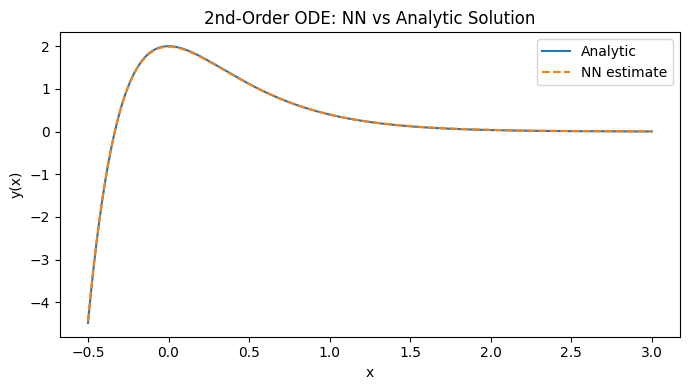

In [4]:
X = np.linspace(-0.5, 3.0, 1000).reshape(-1, 1).astype("float32")
y_pred = net(tf.constant(X)).numpy().flatten()
y_true = problem.true_solution(X.flatten())

plt.figure(figsize=(7, 4))
plt.plot(X, y_true, label="Analytic")
plt.plot(X, y_pred, "--", label="NN estimate")
plt.xlabel("x"); plt.ylabel("y(x)")
plt.title("2nd-Order ODE: NN vs Analytic Solution")
plt.legend(); plt.tight_layout(); plt.show()

In [5]:
test_points = [0.0, -0.5, 2.5]
print(f"{'x':>6} | {'true':>10} | {'pred':>10} | {'err %':>8}")
print("-" * 42)
for xv in test_points:
    xt = tf.constant([[xv]], dtype=tf.float32)
    pred = net(xt).numpy()[0, 0]
    true = problem.true_solution(np.array([xv]))[0]
    pct  = (pred - true) / (true + 1e-12) * 100
    print(f"{xv:>6.1f} | {true:>10.4f} | {pred:>10.4f} | {pct:>7.2f}%")

     x |       true |       pred |    err %
------------------------------------------
   0.0 |     2.0000 |     1.9870 |   -0.65%
  -0.5 |    -4.4817 |    -4.4438 |   -0.85%
   2.5 |     0.0094 |     0.0132 |   40.13%
